In [1]:
import pandas as pd


In [2]:
df = pd.read_parquet('../data/raw/ercot_prices_2024_01.parquet')
print(df.shape)
print(df.info())
print(df.describe())

(2976, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   deliveryDate          2976 non-null   object 
 1   deliveryHour          2976 non-null   int64  
 2   deliveryInterval      2976 non-null   int64  
 3   settlementPoint       2976 non-null   object 
 4   settlementPointType   2976 non-null   object 
 5   settlementPointPrice  2976 non-null   float64
 6   DSTFlag               2976 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 142.5+ KB
None
       deliveryHour  deliveryInterval  settlementPointPrice
count    2976.00000       2976.000000           2976.000000
mean       12.50000          2.500000             33.731126
std         6.92335          1.118222             53.477209
min         1.00000          1.000000            -31.940000
25%         6.75000          1.750000          

In [3]:
import glob

files = glob.glob('../data/raw/ercot_prices_*.parquet')
df = pd.concat([pd.read_parquet(file) for file in files])
df['deliveryDate'] = pd.to_datetime(df['deliveryDate'])

In [4]:
df.shape

(78806, 7)

In [5]:
df['settlementPointPrice'].describe()

count    78806.000000
mean        29.323771
std         70.104692
min        -65.550000
25%         15.450000
50%         21.590000
75%         29.840000
max       4964.860000
Name: settlementPointPrice, dtype: float64

In [6]:
print(df['deliveryDate'].min())
print(df['deliveryDate'].max())
print(df.shape)

2024-01-01 00:00:00
2026-03-31 00:00:00
(78806, 7)


In [7]:
for file in sorted(files):
    temp = pd.read_parquet(file)
    print(file.split('/')[-1], temp.shape)

ercot_prices_2024_01.parquet (2976, 7)
ercot_prices_2024_02.parquet (2784, 7)
ercot_prices_2024_03.parquet (2972, 7)
ercot_prices_2024_04.parquet (2880, 7)
ercot_prices_2024_05.parquet (2976, 7)
ercot_prices_2024_06.parquet (2880, 7)
ercot_prices_2024_07.parquet (2976, 7)
ercot_prices_2024_08.parquet (2976, 7)
ercot_prices_2024_09.parquet (2880, 7)
ercot_prices_2024_10.parquet (2976, 7)
ercot_prices_2024_11.parquet (2884, 7)
ercot_prices_2024_12.parquet (2976, 7)
ercot_prices_2025_01.parquet (2976, 7)
ercot_prices_2025_02.parquet (2688, 7)
ercot_prices_2025_03.parquet (2972, 7)
ercot_prices_2025_04.parquet (2880, 7)
ercot_prices_2025_05.parquet (2976, 7)
ercot_prices_2025_06.parquet (2880, 7)
ercot_prices_2025_07.parquet (2976, 7)
ercot_prices_2025_08.parquet (2976, 7)
ercot_prices_2025_09.parquet (2880, 7)
ercot_prices_2025_10.parquet (2976, 7)
ercot_prices_2025_11.parquet (2884, 7)
ercot_prices_2025_12.parquet (2975, 7)
ercot_prices_2026_01.parquet (2975, 7)
ercot_prices_2026_02.parq

In [8]:
files = glob.glob('../data/raw/ercot_prices_*.parquet')
for file in sorted(files):
    temp = pd.read_parquet(file)
    if temp.shape[0] == 0:
        print(f"EMPTY: {file}")
    else:
        print(f"OK: {file.split('/')[-1]} ({temp.shape[0]} rows)")

OK: ercot_prices_2024_01.parquet (2976 rows)
OK: ercot_prices_2024_02.parquet (2784 rows)
OK: ercot_prices_2024_03.parquet (2972 rows)
OK: ercot_prices_2024_04.parquet (2880 rows)
OK: ercot_prices_2024_05.parquet (2976 rows)
OK: ercot_prices_2024_06.parquet (2880 rows)
OK: ercot_prices_2024_07.parquet (2976 rows)
OK: ercot_prices_2024_08.parquet (2976 rows)
OK: ercot_prices_2024_09.parquet (2880 rows)
OK: ercot_prices_2024_10.parquet (2976 rows)
OK: ercot_prices_2024_11.parquet (2884 rows)
OK: ercot_prices_2024_12.parquet (2976 rows)
OK: ercot_prices_2025_01.parquet (2976 rows)
OK: ercot_prices_2025_02.parquet (2688 rows)
OK: ercot_prices_2025_03.parquet (2972 rows)
OK: ercot_prices_2025_04.parquet (2880 rows)
OK: ercot_prices_2025_05.parquet (2976 rows)
OK: ercot_prices_2025_06.parquet (2880 rows)
OK: ercot_prices_2025_07.parquet (2976 rows)
OK: ercot_prices_2025_08.parquet (2976 rows)
OK: ercot_prices_2025_09.parquet (2880 rows)
OK: ercot_prices_2025_10.parquet (2976 rows)
OK: ercot_

In [9]:
load_files = glob.glob('../data/raw/ercot_load_*.parquet')
for file in load_files:
    year = int(file.split('_')[-2])
    if year < 2024:
        os.remove(file)
        print(f"Deleted: {file}")

In [10]:
load_files = glob.glob('../data/raw/ercot_load_*.parquet')
for file in sorted(load_files):
    temp = pd.read_parquet(file)
    print(f"{'OK' if temp.shape[0] > 0 else 'EMPTY'}: {file.split('/')[-1]} ({temp.shape[0]} rows)")

OK: ercot_load_2024_01.parquet (744 rows)
OK: ercot_load_2024_02.parquet (696 rows)
OK: ercot_load_2024_03.parquet (743 rows)
OK: ercot_load_2024_04.parquet (720 rows)
OK: ercot_load_2024_05.parquet (744 rows)
OK: ercot_load_2024_06.parquet (720 rows)
OK: ercot_load_2024_07.parquet (744 rows)
OK: ercot_load_2024_08.parquet (744 rows)
OK: ercot_load_2024_09.parquet (720 rows)
OK: ercot_load_2024_10.parquet (744 rows)
OK: ercot_load_2024_11.parquet (721 rows)
OK: ercot_load_2024_12.parquet (744 rows)
OK: ercot_load_2025_01.parquet (744 rows)
OK: ercot_load_2025_02.parquet (672 rows)
OK: ercot_load_2025_03.parquet (743 rows)
OK: ercot_load_2025_04.parquet (720 rows)
OK: ercot_load_2025_05.parquet (744 rows)
OK: ercot_load_2025_06.parquet (720 rows)
OK: ercot_load_2025_07.parquet (744 rows)
OK: ercot_load_2025_08.parquet (744 rows)
OK: ercot_load_2025_09.parquet (720 rows)
OK: ercot_load_2025_10.parquet (744 rows)
OK: ercot_load_2025_11.parquet (721 rows)
OK: ercot_load_2025_12.parquet (72

In [11]:
price_files = glob.glob('../data/raw/ercot_prices_*.parquet')
prices = pd.concat([pd.read_parquet(f) for f in sorted(price_files)])
print(prices.shape)

(78806, 7)


In [12]:
laod_files = glob.glob('../data/raw/ercot_load_*.parquet')
load = pd.concat([pd.read_parquet(f) for f in sorted(load_files)])
print(load.shape)

(19679, 12)


In [13]:
weather_files = glob.glob('../data/raw/noaa_weather_*.parquet')
weather = pd.concat([pd.read_parquet(f) for f in sorted(weather_files)])
print(weather.shape)

(821, 6)


EDA 
------


In [14]:
prices.head()


,deliveryDate,deliveryHour,deliveryInterval,settlementPoint,settlementPointType,settlementPointPrice,DSTFlag
0,2024-01-31,1,1,HB_NORTH,HU,15.55,False
1,2024-01-31,1,2,HB_NORTH,HU,15.25,False
2,2024-01-31,1,3,HB_NORTH,HU,14.93,False
3,2024-01-31,1,4,HB_NORTH,HU,14.34,False
4,2024-01-31,2,1,HB_NORTH,HU,14.09,False


In [15]:
print(prices.dtypes)

deliveryDate             object
deliveryHour              int64
deliveryInterval          int64
settlementPoint          object
settlementPointType      object
settlementPointPrice    float64
DSTFlag                    bool
dtype: object


In [16]:
hourly_prices = prices.groupby(['deliveryDate','deliveryHour'])['settlementPointPrice'].mean().reset_index()


In [17]:
print(hourly_prices.head())
print(hourly_prices.shape)

  deliveryDate  deliveryHour  settlementPointPrice
0   2024-01-01             1               14.8700
1   2024-01-01             2               16.0900
2   2024-01-01             3               16.9950
3   2024-01-01             4               17.9525
4   2024-01-01             5               20.6575
(19701, 3)


In [18]:
hourly_prices['timestamp'] = pd.to_datetime(hourly_prices['deliveryDate']) + pd.to_timedelta(hourly_prices['deliveryHour'] - 1, unit='h')

In [19]:
print(hourly_prices[['deliveryDate', 'deliveryHour', 'timestamp', 'settlementPointPrice']].head(25))

   deliveryDate  deliveryHour           timestamp  settlementPointPrice
0    2024-01-01             1 2024-01-01 00:00:00               14.8700
1    2024-01-01             2 2024-01-01 01:00:00               16.0900
2    2024-01-01             3 2024-01-01 02:00:00               16.9950
3    2024-01-01             4 2024-01-01 03:00:00               17.9525
4    2024-01-01             5 2024-01-01 04:00:00               20.6575
5    2024-01-01             6 2024-01-01 05:00:00               22.4700
6    2024-01-01             7 2024-01-01 06:00:00               26.1650
7    2024-01-01             8 2024-01-01 07:00:00               31.0875
8    2024-01-01             9 2024-01-01 08:00:00               40.0950
9    2024-01-01            10 2024-01-01 09:00:00               22.3275
10   2024-01-01            11 2024-01-01 10:00:00               22.2275
11   2024-01-01            12 2024-01-01 11:00:00               21.2525
12   2024-01-01            13 2024-01-01 12:00:00               

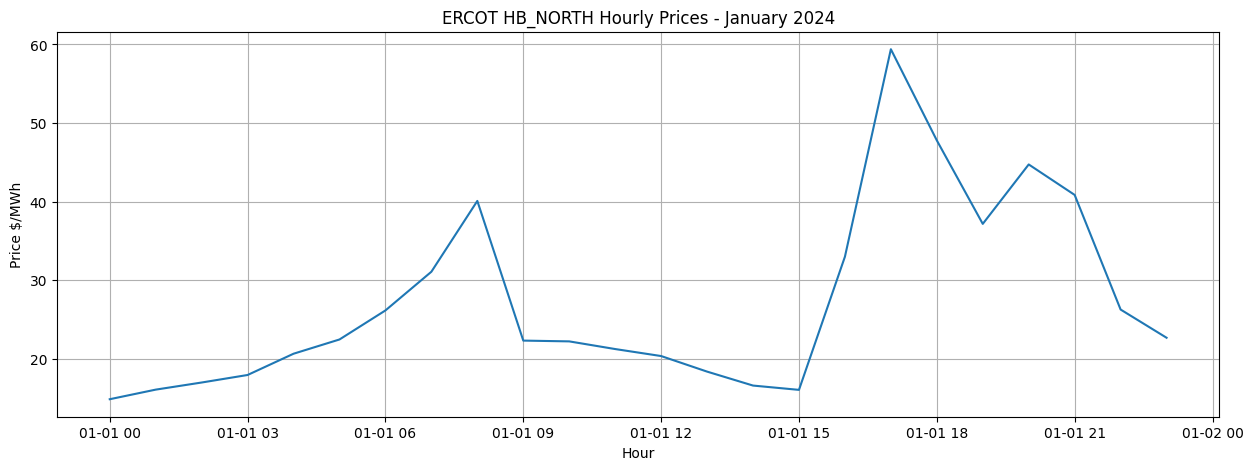

In [20]:
import matplotlib.pyplot as plt

jan_2024 = hourly_prices[hourly_prices['deliveryDate'] == '2024-01-01']

plt.figure(figsize=(15, 5))
plt.plot(jan_2024['timestamp'], jan_2024['settlementPointPrice'])
plt.title('ERCOT HB_NORTH Hourly Prices - January 2024')
plt.xlabel('Hour')
plt.ylabel('Price $/MWh')
plt.grid(True)
plt.show()



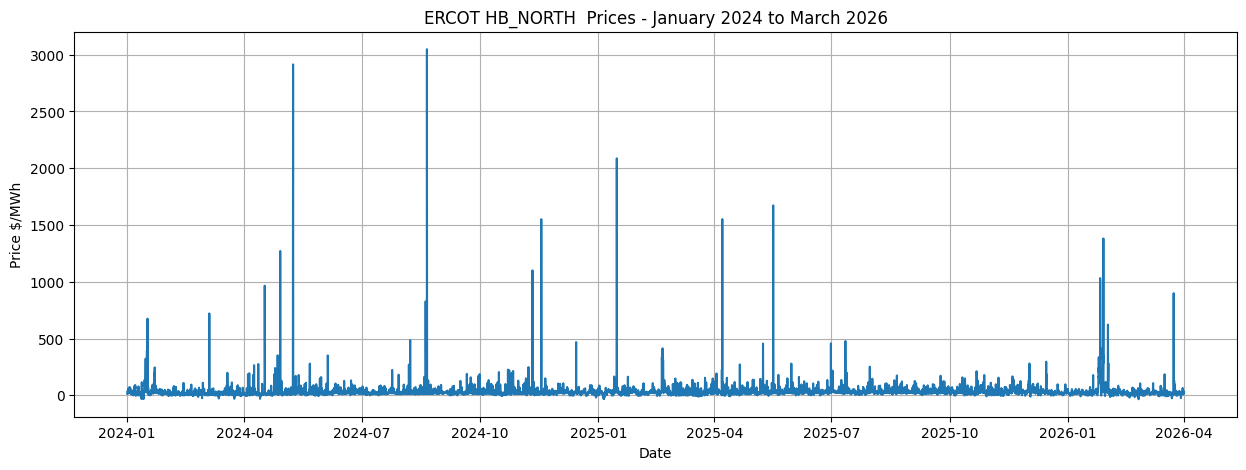

In [21]:
plt.figure(figsize=(15, 5))
plt.plot(hourly_prices['timestamp'], hourly_prices['settlementPointPrice'])
plt.title('ERCOT HB_NORTH  Prices - January 2024 to March 2026')
plt.xlabel('Date')
plt.ylabel('Price $/MWh')
plt.grid(True)
plt.show()

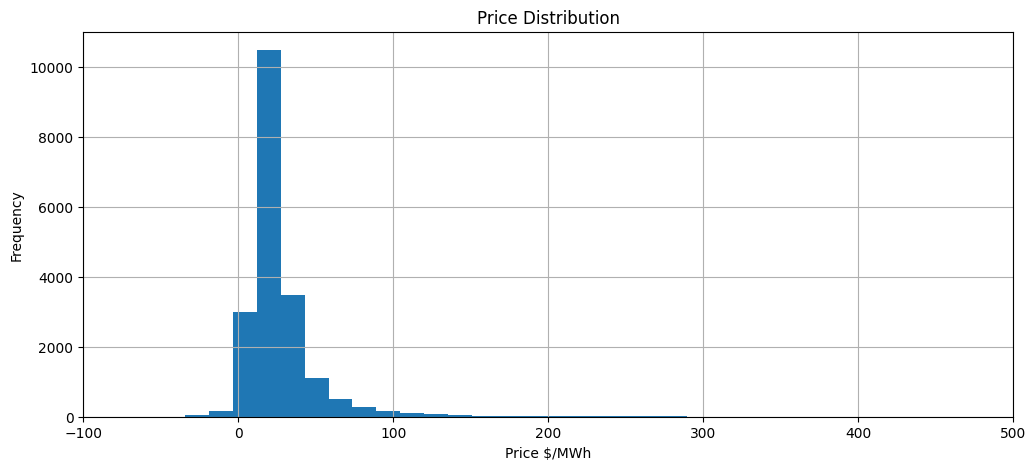

In [22]:
plt.figure(figsize=(12, 5))
hourly_prices['settlementPointPrice'].hist(bins=200)
plt.xlim(-100, 500)
plt.title('Price Distribution')
plt.xlabel('Price $/MWh')
plt.ylabel('Frequency')
plt.show()

In [23]:
print(weather.head())
print(weather.columns.tolist())
print(weather.shape)

        date  AWND   PRCP  RHAV  TMAX  TMIN
0 2024-01-01   4.6    0.0  71.0   8.3   0.6
1 2024-01-02   1.7   99.0  75.0   9.4   0.6
2 2024-01-03   1.8    0.0  76.0  13.3   5.0
3 2024-01-04   4.0    3.0  75.0  14.4   2.2
4 2024-01-05   3.8  112.0  85.0  11.7   7.2
['date', 'AWND', 'PRCP', 'RHAV', 'TMAX', 'TMIN']
(821, 6)


In [24]:
print(weather['date'].dtype)
print(hourly_prices['timestamp'].dtype)

datetime64[ns]
datetime64[ns]


In [25]:
hourly_prices['date'] = hourly_prices['timestamp'].dt.date

In [26]:
print(hourly_prices['date'].dtype)

object


In [27]:
from pandas import to_datetime


weather['date'] = pd.to_datetime(weather['date'])
hourly_prices['date'] = pd.to_datetime(hourly_prices['timestamp'].dt.date)

In [28]:
load_files = glob.glob('../data/raw/ercot_load_*.parquet')
load = pd.concat([pd.read_parquet(f) for f in sorted(load_files)])
print(load.shape)
print(load.columns.tolist())
print(load.head())

(19679, 12)
['operatingDay', 'hourEnding', 'coast', 'east', 'farWest', 'north', 'northC', 'southern', 'southC', 'west', 'total', 'DSTFlag']
  operatingDay hourEnding    coast     east  farWest    north    northC  \
0   2024-01-31      01:00  9635.17  1354.10  6687.17  1371.35  10132.87   
1   2024-01-31      02:00  9507.29  1360.18  6630.59  1361.53   9977.79   
2   2024-01-31      03:00  9479.62  1366.98  6517.71  1377.31  10043.47   
3   2024-01-31      04:00  9577.37  1401.12  6484.47  1395.17  10253.82   
4   2024-01-31      05:00  9862.93  1415.98  6550.87  1441.67  10758.94   

   southern   southC     west     total  DSTFlag  
0   2910.01  6221.62   984.87  39297.17    False  
1   2836.17  6178.05  1006.95  38858.56    False  
2   2855.56  6203.27  1036.02  38879.94    False  
3   2858.87  6326.43  1064.11  39361.36    False  
4   2967.34  6615.92  1116.66  40730.30    False  


In [29]:
print(load['hourEnding'].unique()[:10])
print(load['operatingDay'].dtype)

['01:00' '02:00' '03:00' '04:00' '05:00' '06:00' '07:00' '08:00' '09:00'
 '10:00']
object


In [30]:
load['hourEnding'] = load['hourEnding'].str.split(':').str[0].astype(int)

In [31]:
load['hour'] = load['hourEnding']

In [32]:
load['operatingDay'] = pd.to_datetime(load['operatingDay'])
load['timestamp'] = load['operatingDay'] + pd.to_timedelta(load['hour'] - 1, unit='h')


In [33]:
load_clean = load[['timestamp', 'north', 'total']]

In [34]:
merged = hourly_prices.merge(load_clean, on='timestamp', how='left')

In [35]:
merged['date'] = pd.to_datetime(merged['timestamp'].dt.date)
merged = merged.merge(weather, on='date', how='left')

In [36]:
merged['temp_range'] = merged['TMAX'] - merged['TMIN']
merged = merged.drop(columns=['RHAV'])

In [37]:
merged['temp_avg'] = (merged['TMAX'] + merged['TMIN']) / 2

In [38]:
merged.shape

(19703, 13)

In [39]:
print(merged.isnull().sum())

deliveryDate             0
deliveryHour             0
settlementPointPrice     0
timestamp                0
date                     0
north                   24
total                   24
AWND                     0
PRCP                    48
TMAX                     0
TMIN                     0
temp_range               0
temp_avg                 0
dtype: int64


In [40]:
merged['PRCP'] = merged['PRCP'].fillna(0)

In [41]:
merged['north'] = merged['north'].fillna(method='ffill')
merged['total'] = merged['total'].fillna(method='ffill')

/var/folders/1j/7vqn2jjn2x16036t94r2kz480000gn/T/ipykernel_29279/3770523681.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['north'] = merged['north'].fillna(method='ffill')
/var/folders/1j/7vqn2jjn2x16036t94r2kz480000gn/T/ipykernel_29279/3770523681.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged['total'] = merged['total'].fillna(method='ffill')


In [42]:
print(merged.isnull().sum())

deliveryDate            0
deliveryHour            0
settlementPointPrice    0
timestamp               0
date                    0
north                   0
total                   0
AWND                    0
PRCP                    0
TMAX                    0
TMIN                    0
temp_range              0
temp_avg                0
dtype: int64


In [43]:
merged['deliveryDate'] = pd.to_datetime(merged['deliveryDate'])

Correlation analysis
____

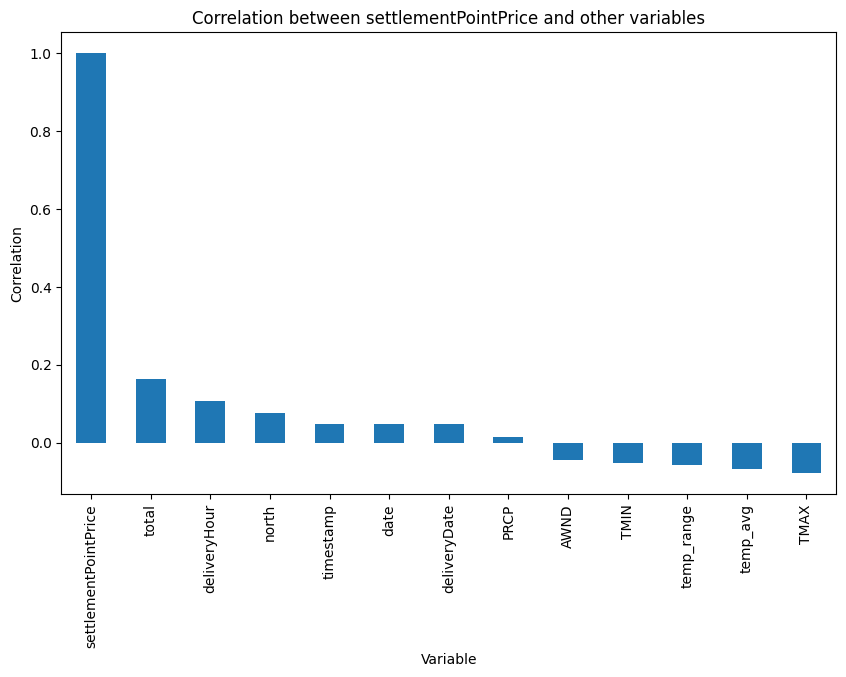

In [44]:
import seaborn as sns

merged.corr()
merged.corr()['settlementPointPrice'].sort_values(ascending=False)
merged.corr()['settlementPointPrice'].sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title('Correlation between settlementPointPrice and other variables')
plt.xlabel('Variable')
plt.ylabel('Correlation')
plt.show()

temp variables have negative correlation , thats because the data covers 27 months including both summer AND winter. In summer, high temperature = high prices. But in winter, low temperature = high prices (heating demand). So temperature has a U-shaped relationship with price — both very hot AND very cold days drive high prices.

the variable deliveryHour has the highest correlation -That tells you time-of-day is your most powerful feature. But it's also a number from 1-24 which has a circular nature — hour 24 and hour 1 are actually adjacent, not 23 hours apart. This implies circular function 

In [45]:
import numpy as np

merged['hour_sin'] = np.sin(2 * np.pi * merged['deliveryHour'] / 24)
merged['hour_cos'] = np.cos(2 * np.pi * merged['deliveryHour'] / 24)

In [46]:
merged['timestamp'].dt.month      # 1-12
merged['timestamp'].dt.dayofweek  # 0-6

0        0
1        0
2        0
3        0
4        0
        ..
19698    1
19699    1
19700    1
19701    1
19702    1
Name: timestamp, Length: 19703, dtype: int32

In [47]:
merged['month_sin']  = np.sin(2*np.pi*merged['timestamp'].dt.month/12)
merged['month_cos']  = np.cos(2*np.pi*merged['timestamp'].dt.month/12)
merged['dow_sin']  = np.sin(2*np.pi*merged['timestamp'].dt.dayofweek/7)
merged['dow_cos']  = np.cos(2*np.pi*merged['timestamp'].dt.dayofweek/7)

merged['comfort_deviation'] = abs(merged['temp_avg'] - 18)





In [48]:
new_features = ['settlementPointPrice', 'hour_sin', 'hour_cos', 
                'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 
                'comfort_deviation', 'AWND', 'PRCP']

merged[new_features].corr()['settlementPointPrice'].sort_values(ascending=False)

settlementPointPrice    1.000000
comfort_deviation       0.147894
hour_cos                0.087849
dow_cos                 0.032462
dow_sin                 0.027503
PRCP                    0.015040
month_cos               0.011296
month_sin              -0.018058
AWND                   -0.045776
hour_sin               -0.095235
Name: settlementPointPrice, dtype: float64

In [49]:
merged['price_lag_1h'] = merged['settlementPointPrice'].shift(1)
merged['price_lag_3h'] = merged['settlementPointPrice'].shift(3)
merged['price_lag_24h'] = merged['settlementPointPrice'].shift(24)
merged['price_lag_48h'] = merged['settlementPointPrice'].shift(48)
merged['price_lag_168h'] = merged['settlementPointPrice'].shift(168)







In [50]:
merged['price_lag_1h'] = merged['settlementPointPrice'].shift(1)
merged['price_lag_3h'] = merged['settlementPointPrice'].shift(3)
merged['price_lag_24h'] = merged['settlementPointPrice'].shift(24)
merged['price_lag_48h'] = merged['settlementPointPrice'].shift(48)
merged['price_lag_168h'] = merged['settlementPointPrice'].shift(168)

merged = merged.dropna()
print(merged.shape)

(19535, 25)


In [51]:
merged['price_rolling_3h'] = merged['settlementPointPrice'].rolling(3).mean().shift(1)
merged['price_rolling_24h'] = merged['settlementPointPrice'].rolling(24).mean().shift(1)

In [52]:
merged = merged.dropna()
print(merged.shape)

(19511, 27)


In [53]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19511 entries, 192 to 19702
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   deliveryDate          19511 non-null  datetime64[ns]
 1   deliveryHour          19511 non-null  int64         
 2   settlementPointPrice  19511 non-null  float64       
 3   timestamp             19511 non-null  datetime64[ns]
 4   date                  19511 non-null  datetime64[ns]
 5   north                 19511 non-null  float64       
 6   total                 19511 non-null  float64       
 7   AWND                  19511 non-null  float64       
 8   PRCP                  19511 non-null  float64       
 9   TMAX                  19511 non-null  float64       
 10  TMIN                  19511 non-null  float64       
 11  temp_range            19511 non-null  float64       
 12  temp_avg              19511 non-null  float64       
 13  hour_sin           

In [54]:
merged.columns  


Index(['deliveryDate', 'deliveryHour', 'settlementPointPrice', 'timestamp',
       'date', 'north', 'total', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'temp_range',
       'temp_avg', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin',
       'dow_cos', 'comfort_deviation', 'price_lag_1h', 'price_lag_3h',
       'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'price_rolling_3h',
       'price_rolling_24h'],
      dtype='object')

In [55]:
merged = merged.drop(columns=[
    'deliveryDate',
    'deliveryHour', 
    'date',
    'TMAX',
    'TMIN'
])

In [56]:

merged.shape

(19511, 22)

In [57]:
merged.columns  

Index(['settlementPointPrice', 'timestamp', 'north', 'total', 'AWND', 'PRCP',
       'temp_range', 'temp_avg', 'hour_sin', 'hour_cos', 'month_sin',
       'month_cos', 'dow_sin', 'dow_cos', 'comfort_deviation', 'price_lag_1h',
       'price_lag_3h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h',
       'price_rolling_3h', 'price_rolling_24h'],
      dtype='object')

In [58]:
import os


merged.to_parquet('../data/processed/features.parquet')

Train_test

In [59]:
train = merged.loc[merged['timestamp'] < '2025-10-01']
test = merged.loc[merged['timestamp'] >= '2025-10-01']

print(train.shape)
print(test.shape)



(15143, 22)
(4368, 22)


In [60]:
train.tail(1)

,settlementPointPrice,timestamp,north,total,AWND,PRCP,temp_range,temp_avg,hour_sin,hour_cos,...,dow_sin,dow_cos,comfort_deviation,price_lag_1h,price_lag_3h,price_lag_24h,price_lag_48h,price_lag_168h,price_rolling_3h,price_rolling_24h
15334,18.545,2025-09-30 23:00:00,1905.7,55031.81,1.6,0.0,10.0,27.2,-2.449294e-16,1.0,...,0.781831,0.62349,9.2,22.75,31.21,31.58,19.0725,30.7375,26.514167,29.363125


In [61]:
test.head(1)

,settlementPointPrice,timestamp,north,total,AWND,PRCP,temp_range,temp_avg,hour_sin,hour_cos,...,dow_sin,dow_cos,comfort_deviation,price_lag_1h,price_lag_3h,price_lag_24h,price_lag_48h,price_lag_168h,price_rolling_3h,price_rolling_24h
15335,19.13,2025-10-01,1845.63,51782.13,1.5,0.0,12.2,26.7,0.258819,0.965926,...,0.974928,-0.222521,8.7,18.545,25.5825,31.4225,19.85,36.77,22.2925,28.82


In [62]:
feature_cols = [col for col in merged.columns if col not in ['settlementPointPrice' , 'timestamp']]
X_train = train[feature_cols]
y_train = train['settlementPointPrice']
X_test = test[feature_cols]
y_test = test['settlementPointPrice']



In [63]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(15143, 20)
(4368, 20)
(15143,)
(4368,)


In [68]:
from quantile_forest import RandomForestQuantileRegressor

model = RandomForestQuantileRegressor(
    n_estimators = 300,
    max_depth = 15,
    min_samples_leaf = 20,
    min_samples_split = 10,
    max_features = "sqrt"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test, quantiles=[0.1, 0.5, 0.9])




In [69]:
y_pred.shape

(4368, 3)

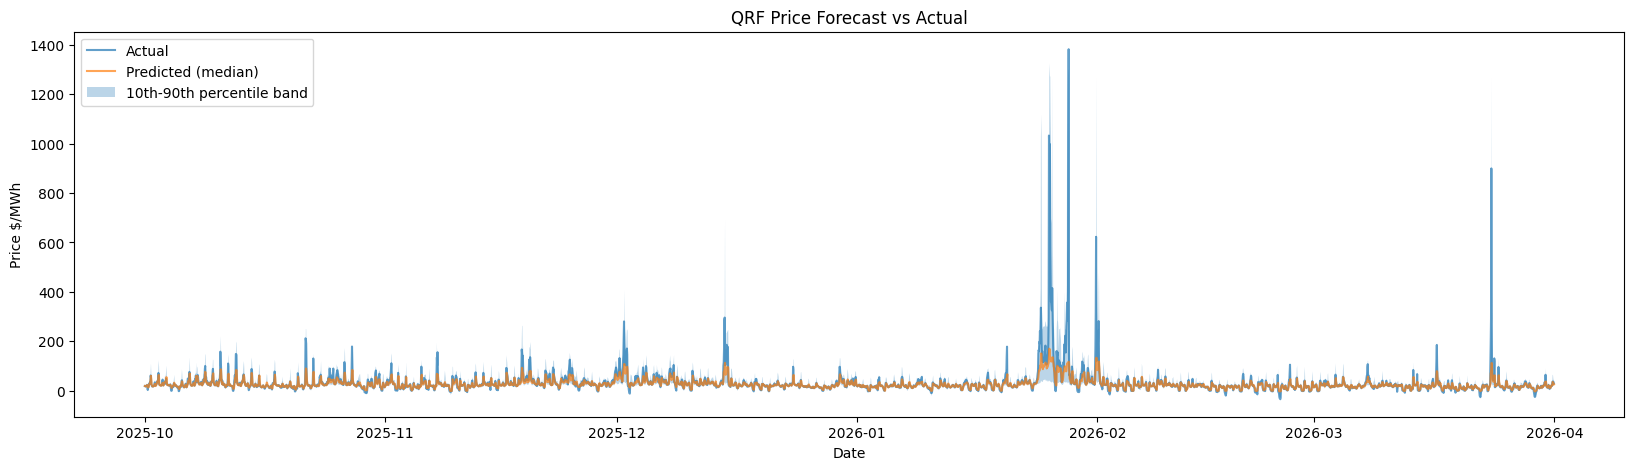

In [70]:
plt.figure(figsize=(20, 5))
plt.plot(test['timestamp'].values, y_test.values, label='Actual', alpha=0.7)
plt.plot(test['timestamp'].values, y_pred[:, 1], label='Predicted (median)', alpha=0.7)
plt.fill_between(test['timestamp'].values, y_pred[:, 0], y_pred[:, 2], alpha=0.3, label='10th-90th percentile band')
plt.title('QRF Price Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price $/MWh')
plt.legend()
plt.show()

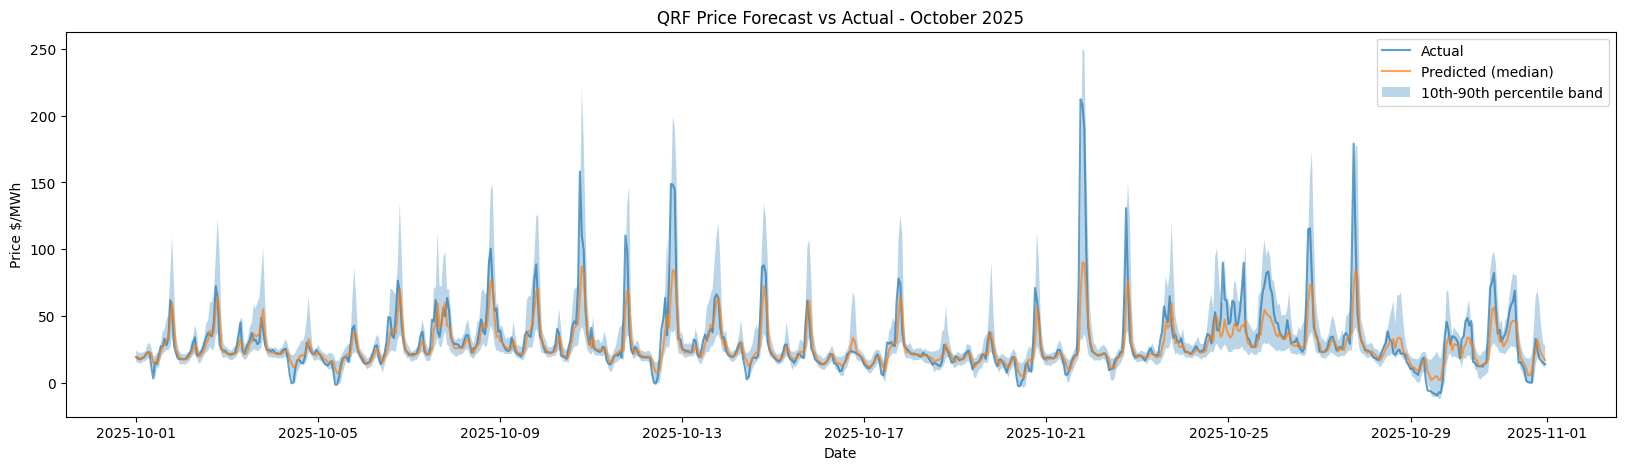

In [71]:
# zoom into one month
mask = (test['timestamp'] >= '2025-10-01') & (test['timestamp'] < '2025-11-01')

plt.figure(figsize=(20, 5))
plt.plot(test[mask]['timestamp'].values, y_test[mask].values, label='Actual', alpha=0.7)
plt.plot(test[mask]['timestamp'].values, y_pred[mask.values, 1], label='Predicted (median)', alpha=0.7)
plt.fill_between(test[mask]['timestamp'].values, 
                 y_pred[mask.values, 0], 
                 y_pred[mask.values, 2], 
                 alpha=0.3, label='10th-90th percentile band')
plt.title('QRF Price Forecast vs Actual - October 2025')
plt.xlabel('Date')
plt.ylabel('Price $/MWh')
plt.legend()
plt.show()

In [72]:
coverage = ((y_test.values >= y_pred[:, 0]) & (y_test.values <= y_pred[:, 2])).mean()
print(f"80% interval coverage: {coverage:.2%}")

80% interval coverage: 89.88%


In [73]:
from sklearn.metrics import mean_pinball_loss

pinball_10 = mean_pinball_loss(y_test, y_pred[:, 0], alpha=0.1)
pinball_50 = mean_pinball_loss(y_test, y_pred[:, 1], alpha=0.5)
pinball_90 = mean_pinball_loss(y_test, y_pred[:, 2], alpha=0.9)

print(f"Pinball Loss Q10: {pinball_10:.3f}")
print(f"Pinball Loss Q50: {pinball_50:.3f}")
print(f"Pinball Loss Q90: {pinball_90:.3f}")

Pinball Loss Q10: 1.878
Pinball Loss Q50: 5.039
Pinball Loss Q90: 2.643


In [74]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred[:, 1]))
print(f"RMSE (median): {rmse:.2f}")

RMSE (median): 42.68


In [ ]:
# Fix: np.percentile(recent_prices, …) raises if len(recent_prices)==0.
# Common cause: recent = prices.iloc[max(0, i - W): i]  → at i==0 this is [:0] (empty).

def rolling_p30_p70(recent_prices, fallback):
    """Percentiles of past prices; if no history yet, use fallback (e.g. current_price or q50)."""
    rp = np.asarray(recent_prices, dtype=float).ravel()
    rp = rp[np.isfinite(rp)]
    if rp.size == 0:
        fb = float(fallback)
        return fb, fb
    return float(np.percentile(rp, 30)), float(np.percentile(rp, 70))

# In smart_strategy, replace:
#   p30 = np.percentile(recent_prices, 30)
#   p70 = np.percentile(recent_prices, 70)
# with:
#   p30, p70 = rolling_p30_p70(recent_prices, current_price)  # or fallback=q50

# In backtest loop (before calling smart_strategy), ensure non-empty history, e.g.:
#   recent_prices = test_df['settlementPointPrice'].iloc[max(0, i - lookback): i].values
#   if recent_prices.size == 0:
#       recent_prices = np.array([current_price])


backtesting engine


In [76]:
def dispatch(action, soc, price, capacity=100, max_rate=25, efficiency=0.85):
    # action: 'charge', 'discharge', 'idle'
    # soc: current state of charge in MWh
    # price: current market price $/MWh
    # returns: new_soc, cash_flow

    if action == 'charge':
        # available room in battery
        available_capacity = capacity - soc
        
        # actual amount we can charge this hour
        charge_amount = min(max_rate, available_capacity)
        
        # efficiency loss while charging
        energy_stored = charge_amount * efficiency
        
        # update SOC
        new_soc = soc + energy_stored
        
        # buying electricity = negative cash flow
        cash_flow = -charge_amount * price
        
        return new_soc, cash_flow

    elif action == 'discharge':
        # actual amount we can discharge
        discharge_amount = min(max_rate, soc)
        
        # usable energy delivered after efficiency loss
        energy_sold = discharge_amount * efficiency
        
        # update SOC
        new_soc = soc - discharge_amount
        
        # selling electricity = positive cash flow
        cash_flow = energy_sold * price
        
        return new_soc, cash_flow

    else:  # idle
        return soc, 0

Naive strategy 

In [77]:

def naive_strategy(hour, soc):
    # hour is 0-23
    if hour <=5:
        return 'charge'
    elif hour>=16 and hour<=21:
        return 'discharge'
    else:
        return 'idle'


In [84]:
def smart_strategy(current_price, q10, q50, q90, soc, recent_prices, capacity=100):
    # current_price: actual price this hour
    if len(recent_prices) < 2:
        return 'idle'
    p30 = np.percentile(recent_prices, 30)
    p70 = np.percentile(recent_prices, 70)

    soc_ratio = soc / capacity

    can_charge = soc_ratio < 0.90
    can_discharge = soc_ratio > 0.10

    #QRF based decision 

    strong_upside = (q90 - current_price) > 10

    if (current_price < p30 and strong_upside and can_charge):
        return 'charge'
    elif (current_price > p70 and can_discharge):
        return 'discharge'
    else:
        return 'idle'
    

In [85]:
def backtest(test_df, predictions, initial_soc=50):
    soc_naive = initial_soc
    soc_smart = initial_soc
    
    revenue_naive = 0
    revenue_smart = 0
    
    # store results for analysis
    results = []
    
    for i in range(len(test_df)):
        current_price = test_df['settlementPointPrice'].iloc[i]
        hour = test_df['timestamp'].iloc[i].hour
        
        q10, q50, q90 = predictions[i, 0], predictions[i, 1], predictions[i, 2]
        
        # recent prices for dynamic threshold
        recent_prices = test_df['settlementPointPrice'].iloc[max(0, i-24):i].values
        
        # naive decision
        action_naive = naive_strategy(hour, soc_naive)
        soc_naive, cf_naive = dispatch(action_naive, soc_naive, current_price)
        revenue_naive += cf_naive
        # smart decision
        action_smart = smart_strategy(current_price, q10, q50, q90, soc_smart, recent_prices)
        soc_smart, cf_smart = dispatch(action_smart, soc_smart, current_price)
        revenue_smart += cf_smart
        
        # dispatch both
        results.append({
            'timestamp': test_df['timestamp'].iloc[i],
            'actual_price': current_price,
            'predicted_price': q50,
            'soc_naive': soc_naive,
            'soc_smart': soc_smart,
            'action_naive': action_naive,
            'action_smart': action_smart,
            'cashflow_naive': cf_naive,
            'cashflow_smart': cf_smart
        })      
        # track results
        
    return pd.DataFrame(results)

In [86]:
results_df = backtest(test.reset_index(drop=True), y_pred)
print(results_df.shape)
print(f"Naive Revenue: ${results_df['cashflow_naive'].sum():,.2f}")
print(f"Smart Revenue: ${results_df['cashflow_smart'].sum():,.2f}")

(4368, 9)
Naive Revenue: $60,449.52
Smart Revenue: $235,674.07


In [88]:
import joblib
joblib.dump(model, '../models/qrf_model.joblib')
results_df.to_parquet('../data/processed/backtest_results.parquet')

In [89]:
results_df['cumrev_naive'] = results_df['cashflow_naive'].cumsum()
results_df['cumrev_smart'] = results_df['cashflow_smart'].cumsum()

In [90]:
results_df.to_csv('../data/processed/dashboard_performance.csv', index=False)

In [91]:
forecast_df = test.reset_index(drop=True).copy()
forecast_df['q10'] = y_pred[:, 0]
forecast_df['q50'] = y_pred[:, 1]
forecast_df['q90'] = y_pred[:, 2]
forecast_df.to_csv('../data/processed/dashboard_forecast.csv', index=False)

In [92]:
import pandas as pd
df = pd.read_csv('../data/processed/dashboard_forecast.csv')
print(df.columns.tolist())
print(df.head(2))

['settlementPointPrice', 'timestamp', 'north', 'total', 'AWND', 'PRCP', 'temp_range', 'temp_avg', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'comfort_deviation', 'price_lag_1h', 'price_lag_3h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'price_rolling_3h', 'price_rolling_24h', 'q10', 'q50', 'q90']
   settlementPointPrice            timestamp    north     total  AWND  PRCP  \
0               19.1300  2025-10-01 00:00:00  1845.63  51782.13   1.5   0.0   
1               18.0275  2025-10-01 01:00:00  1890.40  49463.56   1.5   0.0   

   temp_range  temp_avg  hour_sin  hour_cos  ...  price_lag_1h  price_lag_3h  \
0        12.2      26.7  0.258819  0.965926  ...        18.545       25.5825   
1        12.2      26.7  0.500000  0.866025  ...        19.130       22.7500   

   price_lag_24h  price_lag_48h  price_lag_168h  price_rolling_3h  \
0        31.4225        19.8500         36.7700         22.292500   
1        26.5875        19.1075         29.557

In [93]:
forecast_df = test.reset_index(drop=True).copy()
forecast_df = forecast_df[['timestamp', 'settlementPointPrice']].rename(
    columns={'settlementPointPrice': 'actual_price'}
)
forecast_df['q10'] = y_pred[:, 0]
forecast_df['q50'] = y_pred[:, 1]
forecast_df['q90'] = y_pred[:, 2]
forecast_df.to_csv('../data/processed/dashboard_forecast.csv', index=False)